In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

!pip -q install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.0 MB/s eta 0:00:0000:01


In [19]:
df = pd.read_csv("/kaggle/input/airlinedatasetcleaned/AirlineScrappedReview_Cleaned.csv")

# Prepare text (handle NaNs / whitespace)
text_col = "Review_content" if "Review_content" in df.columns else "review_content"
if text_col not in df.columns:
    raise KeyError(f"Couldn't find a review text column. Expected 'Review_Content' (or 'review_content'). Columns found: {list(df.columns)}")

df[text_col] = df[text_col].astype(str).fillna("").str.strip()

# Create the analyzer and add ONE sentiment column (label only)
analyzer = SentimentIntensityAnalyzer()

def label_sentiment(text: str) -> str:
    score = analyzer.polarity_scores(text)['compound']  # -1 (neg) .. +1 (pos)
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df[text_col].apply(label_sentiment)

# Save the augmented file 
out_path = "AirlineScrappedReview_Sentiment.csv"
df.to_csv(out_path, index=False)
print(f"Saved with Sentiment column ➜ {out_path}")

Saved with Sentiment column ➜ AirlineScrappedReview_Sentiment.csv


In [23]:
# --- Clean 'Unknown' in Traveller_Type and Class by imputing the mode (most frequent non-Unknown) ---
for col in ['Traveller_Type', 'Class']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        known_mask = df[col].str.casefold() != 'unknown'
        if known_mask.any():
            mode_val = df.loc[known_mask, col].mode().iloc[0]
            df.loc[~known_mask, col] = mode_val

# --- Save cleaned CSV ---
out_path = "AirlineScrappedReview_Cleaned_ModeImputed.csv"
df.to_csv(out_path, index=False)
print(f"Saved cleaned file to: {out_path}")


Saved cleaned file to: AirlineScrappedReview_Cleaned_ModeImputed.csv


In [25]:
#Group by traveler type and seat type
grouped = df.groupby(['Traveller_Type', 'Class'])['Rating'].mean().reset_index()

# Sort to identify highest and lowest
highest = grouped.loc[grouped['Rating'].idxmax()]
lowest = grouped.loc[grouped['Rating'].idxmin()]

print("Highest Rated Combination:")
print(highest)

print("\nLowest Rated Combination:")
print(lowest)

Highest Rated Combination:
Traveller_Type    Solo Leisure
Class              First Class
Rating                6.627907
Name: 14, dtype: object

Lowest Rated Combination:
Traveller_Type          Various
Class             Economy Class
Rating                      1.0
Name: 16, dtype: object


In [22]:
df.head(20)

,Passanger_Name,Flying_Date,Route,Rating,Verified,Review_title,Review_content,Traveller_Type,Class,Start_Location,End_Location,Layover_Route,Start_Latitude,Start_Longitude,Start_Address,End_Latitude,End_Longitude,End_Address,Sentiment
0,Paige Boet,June 2023,New Orleans to London,1,Trip Verified,The airline lost my luggage,The airline lost my luggage and was absolutely...,Solo Leisure,Economy Class,New Orleans,London,NaN,29.975998,-90.078213,"New Orleans, Orleans Parish, Louisiana, United...",51.507446,-0.127765,"London, Greater London, England, United Kingdom",Negative
1,S Layne,March 2023,London to Amman,1,Trip Verified,fully refunded by our travel insurance,"We booked on the BA website, round trip flight...",Couple Leisure,Business Class,London,Amman,NaN,51.507446,-0.127765,"London, Greater London, England, United Kingdom",31.951569,35.923963,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,...",Neutral
2,E Lanewoski,NaN,Heathrow to Bodrum,2,Trip Verified,no boarding drinks provided,"First time flying with BA business class, neve...",Solo Leisure,Business Class,London Heathrow,Bodrum,NaN,51.467739,-0.458780,"London Heathrow Airport, The Beacon Roundabout...",37.034399,27.430651,"Bodrum, Muğla, Ege Bölgesi, Türkiye",Negative
3,Joel Burman,June 2023,Amman to London,4,Not Verified,WiFi didn't work,You can buy sandwiches and crisps but don't ex...,Solo Leisure,Economy Class,Amman,London,NaN,31.951569,35.923963,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,...",51.507446,-0.127765,"London, Greater London, England, United Kingdom",Negative
4,R Vines,NaN,London City to Ibiza,7,Trip Verified,stick with economy,This is a two-for-one review covering economy ...,Family Leisure,Business Class,London City,Ibiza,NaN,42.953765,-81.229153,"London (city), Ontario, N6C 0A7, Canada",38.974390,1.419746,"Eivissa, Illes Balears, España",Positive
5,M King,June 2023,London to Washington,1,Trip Verified,Communication is terrible,Absolutely horrible airline. Communication is ...,Couple Leisure,Economy Class,London,Washington,NaN,51.507446,-0.127765,"London, Greater London, England, United Kingdom",38.895037,-77.036543,"Washington, District of Columbia, United States",Negative
6,C Dean,NaN,Amsterdam to London,1,Trip Verified,delays and cancellations,Having experienced delays and cancellations de...,Business,Business Class,Amsterdam,London,NaN,52.373080,4.892453,"Amsterdam, Noord-Holland, Nederland",51.507446,-0.127765,"London, Greater London, England, United Kingdom",Positive
7,Richard Hodges,NaN,London Heathrow to Kalamata,7,Trip Verified,Economy class seating was truly dreadful,Travelled to Heathrow to Kalamata and return j...,Couple Leisure,Economy Class,London Heathrow,Kalamata,NaN,51.467739,-0.458780,"London Heathrow Airport, The Beacon Roundabout...",-7.750000,28.250000,"Kalamata, Tanganyika, République démocratique ...",Positive
8,Carol Willmore,June 2023,London to Funchal,1,Not Verified,flight failed at every level,This flight failed at every level. We were del...,Couple Leisure,Economy Class,London,Funchal,NaN,51.507446,-0.127765,"London, Greater London, England, United Kingdom",32.649650,-16.908678,"Funchal, Madeira, Portugal",Positive
9,Nadine Kohler,June 2023,Marseille to Seattle via London Heathrow,1,Not Verified,BA refuses to make it right,Beware of British Airways and their marketing ...,Family Leisure,Economy Class,Marseille,Seattle,London Heathrow,43.296174,5.369953,"Marseille, Bouches-du-Rhône, Provence-Alpes-Cô...",47.603832,-122.330062,"Seattle, King County, Washington, United States",Negative


Top 10 Most Popular Flight Routes:
 route  Bookings
AKLKUL      2680
PENTPE       924
MELSGN       842
ICNSIN       801
DMKKIX       744
ICNSYD       695
DMKPER       679
DPSICN       666
DMKOOL       655
MELPEN       649


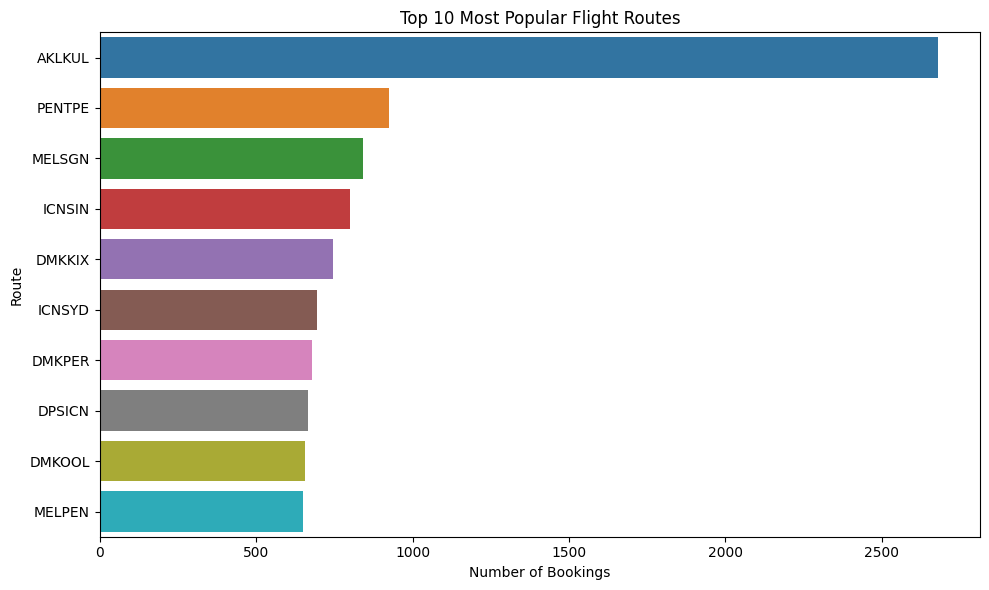

In [28]:
df2 = pd.read_csv("/kaggle/input/airline-passangers-booking-data/Passanger_booking_data.csv")

# Clean Route column (remove NaNs/blank/whitespace-only)
df2['route'] = df2['route'].astype(str).str.strip()
df2 = df2[df2['route'].notna() & (df2['route'] != '')]

# Compute Top 10 routes 
top_routes = df2['route'].value_counts().head(10).reset_index()
top_routes.columns = ['route', 'Bookings']

# Print results 
print("Top 10 Most Popular Flight Routes:")
print(top_routes.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=top_routes, x='Bookings', y='route')
plt.title("Top 10 Most Popular Flight Routes")
plt.xlabel("Number of Bookings")
plt.ylabel("Route")
plt.tight_layout()
plt.show()

Booking distribution by flight hour:
flight_hour
0     1539
1     2089
2     2642
3     2655
4     2843
5     2851
6     3051
7     3126
8     3165
9     3133
10    3085
11    3110
12    3163
13    3101
14    2833
15    2234
16    1557
17     861
18     439
19     295
20     276
21     389
22     579
23     986
Name: count, dtype: int64


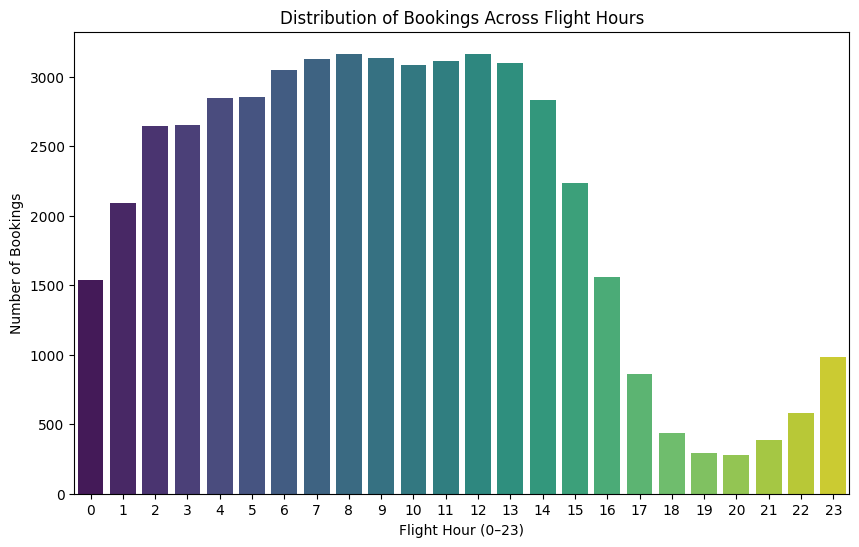

In [29]:
# Convert to numeric (if stored as string)
df2['flight_hour'] = pd.to_numeric(df2['flight_hour'], errors='coerce')

# Drop missing hours if any
df2 = df2.dropna(subset=['flight_hour'])

# Group by flight hour
hourly_bookings = df2['flight_hour'].value_counts().sort_index()

print("Booking distribution by flight hour:")
print(hourly_bookings)

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(x=hourly_bookings.index, y=hourly_bookings.values, palette='viridis')
plt.title("Distribution of Bookings Across Flight Hours")
plt.xlabel("Flight Hour (0–23)")
plt.ylabel("Number of Bookings")
plt.xticks(range(0,24))
plt.show()